In [ ]:
!pip install transformers torch scikit-learn
import pandas as pd
import torch
from transformers import GPT2Tokenizer, GPT2Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')

# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)

# 1. Persiapkan tokenizer dan model GPT
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Tetapkan pad_token
model = GPT2Model.from_pretrained("gpt2")

# Fungsi untuk ekstraksi fitur menggunakan GPT
def extract_features_from_email(email_texts):
    features = []
    for text in email_texts:
        # Tokenisasi dan padding
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        # Ambil rata-rata embedding dari semua token
        last_hidden_state = outputs.last_hidden_state
        email_embedding = last_hidden_state.mean(dim=1).squeeze().numpy()
        features.append(email_embedding)
    return np.array(features)

# 2. Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# 3: Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(float).tolist()  # Pastikan label berupa float

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]

# 4. Ekstraksi fitur untuk dataset menggunakan GPT
print("Ekstraksi fitur menggunakan GPT sedang berlangsung...")
email_features = extract_features_from_email(emails)
print("Ekstraksi fitur menggunakan GPT selesai.")

df = pd.DataFrame(email_features)

# Simpan ke file CSV
df.to_csv("email_features.csv", index=False)

print("File CSV berhasil disimpan!")

# 5. Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(email_features, labels, test_size=0.2, random_state=42)

# 6. Latih model regresi linear menggunakan fitur dari GPT
model_gpt = LinearRegression()
model_gpt.fit(X_train, y_train)

# 7. Prediksi dan evaluasi model menggunakan GPT
y_pred_gpt = model_gpt.predict(X_test)
mse = mean_squared_error(y_test, y_pred_gpt)
r2 = r2_score(y_test, y_pred_gpt)

# Menghitung metrik evaluasi
y_pred_gpt_binary = (y_pred_gpt > 0.5).astype(int)  # Mengubah prediksi menjadi biner
accuracy = accuracy_score(y_test, y_pred_gpt_binary)
precision = precision_score(y_test, y_pred_gpt_binary)
recall = recall_score(y_test, y_pred_gpt_binary)
f1 = f1_score(y_test, y_pred_gpt_binary)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# 8. Prediksi untuk email baru
input_mail = ["this is my grade"]

# Preprocessing email baru
input_mail_processed = (preprocess_text(mail) for mail in input_mail)
# Convert text to feature vectors using GPT
input_data_features = extract_features_from_email(input_mail_processed)

# 9. Prediksi skor spam
spam_score = model_gpt.predict(input_data_features)
print(f"Spam Score: {spam_score[0]:.2f}")

if spam_score[0] > 0.5:
    print("Kemungkinan besar spam")
else:
    print("Kemungkinan besar ham")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

   Unnamed: 0 label                                               text  \
0         605   ham  subject enron methanol meter follow note gave ...   
1        2349   ham  subject hpl nom januari see attach file hplnol...   
2        3624   ham  subject neon retreat ho ho ho around wonder ti...   
3        4685  spam  subject photoshop window offic cheap main tren...   
4        2030   ham  subject indian spring deal book teco pvr reven...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Ekstraksi fitur menggunakan GPT sedang berlangsung...
Ekstraksi fitur menggunakan GPT selesai.
File CSV berhasil disimpan!
Mean Squared Error: 0.04600738734006882
R² Score: 0.773307740688324
Akurasi: 0.9729468599033816
Precision: 0.9461279461279462
Recall: 0.9590443686006825
F1 Score: 0.9525423728813559
Spam Score: 1.41
Kemungkinan besar spam


Dipisah pisah dan mneggunakan grafik

In [ ]:
!pip install transformers torch scikit-learn matplotlib seaborn
import pandas as pd
import torch
from transformers import GPT2Tokenizer, GPT2Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()


In [ ]:
# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)


In [ ]:
# Fungsi untuk ekstraksi fitur menggunakan GPT
def extract_features_from_email(email_texts):
    features = []
    for text in email_texts:
        # Tokenisasi dan padding
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        # Ambil rata-rata embedding dari semua token
        last_hidden_state = outputs.last_hidden_state
        email_embedding = last_hidden_state.mean(dim=1).squeeze().numpy()
        features.append(email_embedding)
    return np.array(features)


In [ ]:
# Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(int).tolist()  # Pastikan label berupa integer untuk klasifikasi

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]


   Unnamed: 0 label                                               text  \
0         605   ham  subject enron methanol meter follow note gave ...   
1        2349   ham  subject hpl nom januari see attach file hplnol...   
2        3624   ham  subject neon retreat ho ho ho around wonder ti...   
3        4685  spam  subject photoshop window offic cheap main tren...   
4        2030   ham  subject indian spring deal book teco pvr reven...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  


In [ ]:
# Ekstraksi fitur untuk dataset menggunakan GPT
print("Ekstraksi fitur menggunakan GPT sedang berlangsung...")
email_features = extract_features_from_email(emails)
print("Ekstraksi fitur menggunakan GPT selesai.")

df = pd.DataFrame(email_features)

# Simpan ke file CSV
df.to_csv("email_features.csv", index=False)

print("File CSV berhasil disimpan!")


Ekstraksi fitur menggunakan GPT sedang berlangsung...
Ekstraksi fitur menggunakan GPT selesai.
File CSV berhasil disimpan!


In [ ]:
# Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(email_features, labels, test_size=0.2, random_state=42)


In [ ]:
# Latih model regresi logistik menggunakan fitur dari GPT
model_gpt = LogisticRegression(max_iter=1000)
model_gpt.fit(X_train, y_train)

# Prediksi dan evaluasi model menggunakan GPT
y_pred_gpt = model_gpt.predict(X_test)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred_gpt)
precision = precision_score(y_test, y_pred_gpt)
recall = recall_score(y_test, y_pred_gpt)
f1 = f1_score(y_test, y_pred_gpt)
roc_auc = roc_auc_score(y_test, model_gpt.predict_proba(X_test)[:, 1])  # ROC AUC menggunakan probabilitas

# Menampilkan hasil metrik evaluasi
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")


Akurasi: 0.9758454106280193
Precision: 0.95578231292517
Recall: 0.9590443686006825
F1 Score: 0.9574105621805792
ROC AUC: 0.9935466362473897


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Prediksi untuk email baru
input_mail = ["this is my grade"]

# Preprocessing email baru
input_mail_processed = [preprocess_text(mail) for mail in input_mail]
# Convert text to feature vectors using GPT
input_data_features = extract_features_from_email(input_mail_processed)

# Prediksi klasifikasi spam
spam_prediction = model_gpt.predict(input_data_features)
print(f"Prediksi Klasifikasi: {'Spam' if spam_prediction[0] == 1 else 'Ham'}")


Prediksi Klasifikasi: Spam


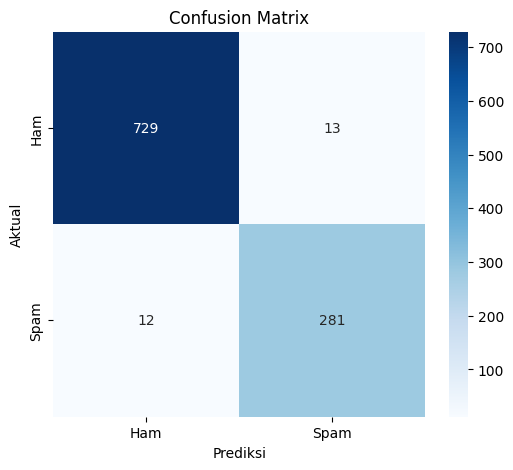

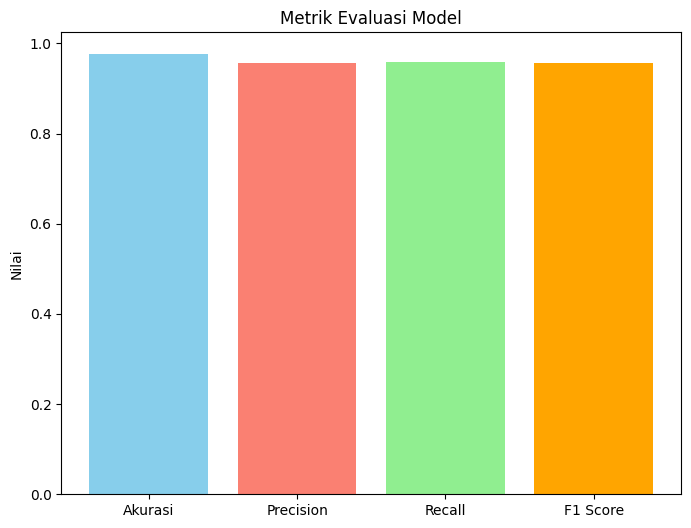

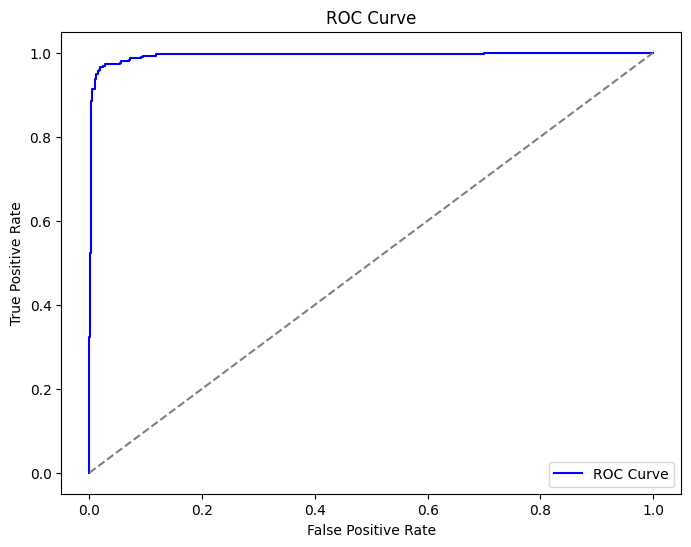

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gpt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Grafik Precision, Recall, F1-Score
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Akurasi', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model_gpt.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Tanpa Ekstraksi fitur

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Unnamed: 0 label                                               text  \
0         605   ham  subject enron methanol meter follow note gave ...   
1        2349   ham  subject hpl nom januari see attach file hplnol...   
2        3624   ham  subject neon retreat ho ho ho around wonder ti...   
3        4685  spam  subject photoshop window offic cheap main tren...   
4        2030   ham  subject indian spring deal book teco pvr reven...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Akurasi: 0.7227053140096619
Precision: 0.7142857142857143
Recall: 0.034129692832764506
F1 Score: 0.06514657980456026
ROC AUC: 0.5365583286569828
Prediksi Klasifikasi: Ham


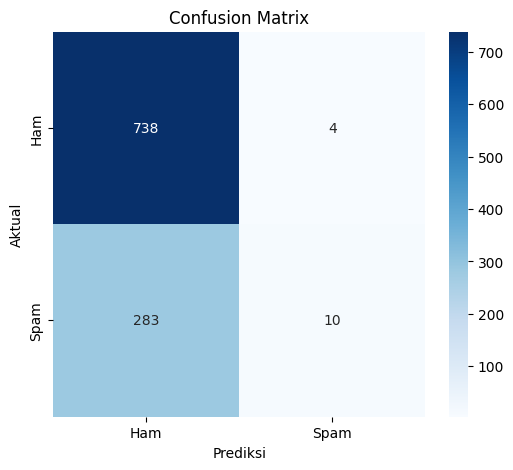

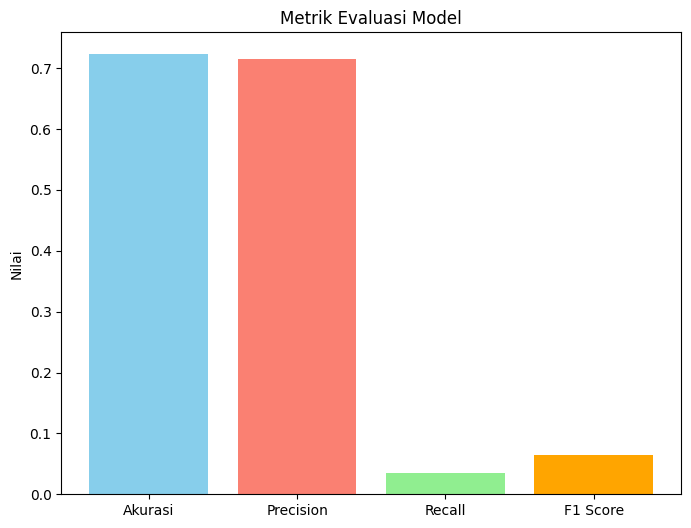

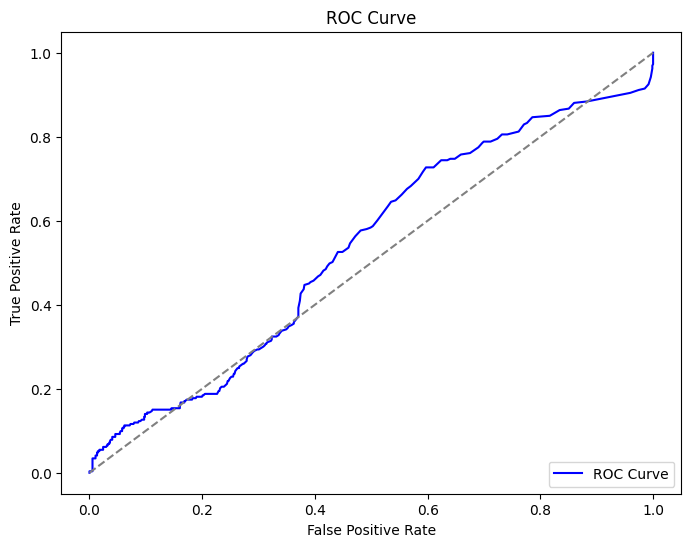

In [ ]:
!pip install scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')

# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)

# 1. Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# 2: Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(int).tolist()  # Pastikan label berupa integer untuk klasifikasi

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]

# 3. Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.2, random_state=42)

# 4. Latih model regresi logistik menggunakan fitur langsung (tanpa ekstraksi fitur)
model = LogisticRegression(max_iter=1000)

# Misalnya kita hanya melatih model dengan panjang email atau fitur numerik lain
# Sebagai contoh, kita hanya akan menggunakan panjang email sebagai fitur numerik
X_train_len = np.array([len(email.split()) for email in X_train]).reshape(-1, 1)
X_test_len = np.array([len(email.split()) for email in X_test]).reshape(-1, 1)

model.fit(X_train_len, y_train)

# 5. Prediksi dan evaluasi model
y_pred = model.predict(X_test_len)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_len)[:, 1])  # ROC AUC menggunakan probabilitas

# Menampilkan hasil metrik evaluasi
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

# 6. Prediksi untuk email baru (gunakan panjang email sebagai fitur untuk prediksi)
input_mail = ["this is my grade"]

# Menghitung panjang email baru
input_mail_len = np.array([len(mail.split()) for mail in input_mail]).reshape(-1, 1)

# Prediksi klasifikasi spam
spam_prediction = model.predict(input_mail_len)
print(f"Prediksi Klasifikasi: {'Spam' if spam_prediction[0] == 1 else 'Ham'}")

# 7. Visualisasi
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Grafik Precision, Recall, F1-Score
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Akurasi', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_len)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


70:30

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Unnamed: 0 label                                               text  \
0         605   ham  subject enron methanol meter follow note gave ...   
1        2349   ham  subject hpl nom januari see attach file hplnol...   
2        3624   ham  subject neon retreat ho ho ho around wonder ti...   
3        4685  spam  subject photoshop window offic cheap main tren...   
4        2030   ham  subject indian spring deal book teco pvr reven...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Akurasi: 0.7235824742268041
Precision: 0.5416666666666666
Recall: 0.030162412993039442
F1 Score: 0.05714285714285714
ROC AUC: 0.5433994755262846
Prediksi Klasifikasi: Ham


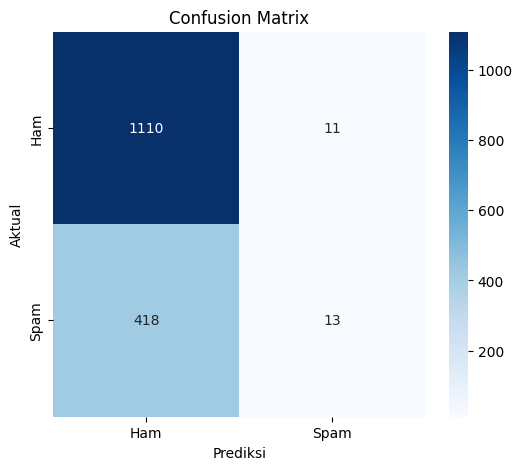

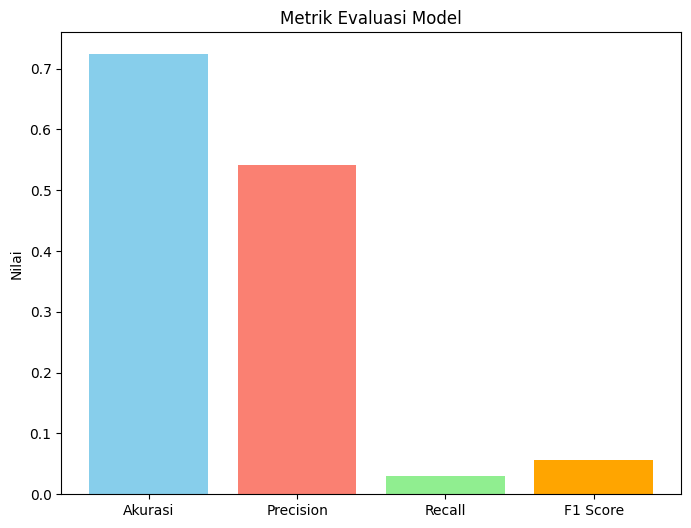

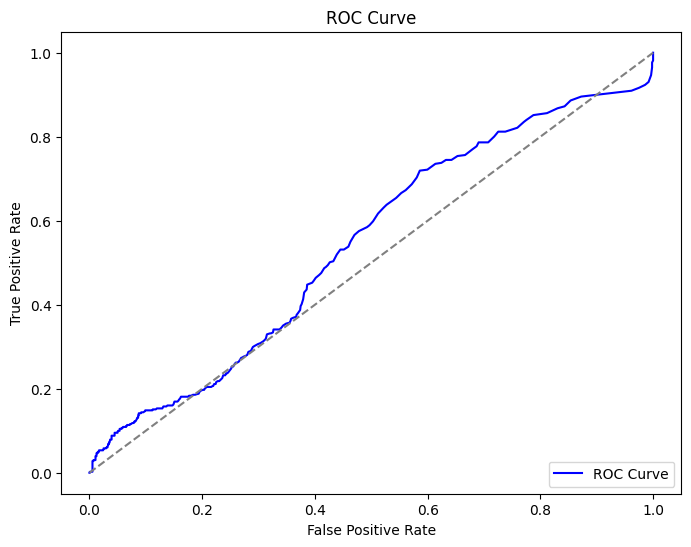

In [ ]:
!pip install scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')

# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)

# 1. Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# 2: Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(int).tolist()  # Pastikan label berupa integer untuk klasifikasi

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]

# 3. Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.3, random_state=42)

# 4. Latih model regresi logistik menggunakan fitur langsung (tanpa ekstraksi fitur)
model = LogisticRegression(max_iter=1000)

# Misalnya kita hanya melatih model dengan panjang email atau fitur numerik lain
# Sebagai contoh, kita hanya akan menggunakan panjang email sebagai fitur numerik
X_train_len = np.array([len(email.split()) for email in X_train]).reshape(-1, 1)
X_test_len = np.array([len(email.split()) for email in X_test]).reshape(-1, 1)

model.fit(X_train_len, y_train)

# 5. Prediksi dan evaluasi model
y_pred = model.predict(X_test_len)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_len)[:, 1])  # ROC AUC menggunakan probabilitas

# Menampilkan hasil metrik evaluasi
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

# 6. Prediksi untuk email baru (gunakan panjang email sebagai fitur untuk prediksi)
input_mail = ["this is my grade"]

# Menghitung panjang email baru
input_mail_len = np.array([len(mail.split()) for mail in input_mail]).reshape(-1, 1)

# Prediksi klasifikasi spam
spam_prediction = model.predict(input_mail_len)
print(f"Prediksi Klasifikasi: {'Spam' if spam_prediction[0] == 1 else 'Ham'}")

# 7. Visualisasi
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Grafik Precision, Recall, F1-Score
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Akurasi', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_len)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


90:10

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Unnamed: 0 label                                               text  \
0         605   ham  subject enron methanol meter follow note gave ...   
1        2349   ham  subject hpl nom januari see attach file hplnol...   
2        3624   ham  subject neon retreat ho ho ho around wonder ti...   
3        4685  spam  subject photoshop window offic cheap main tren...   
4        2030   ham  subject indian spring deal book teco pvr reven...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Akurasi: 0.7239382239382239
Precision: 0.8333333333333334
Recall: 0.034013605442176874
F1 Score: 0.06535947712418301
ROC AUC: 0.5041898160881604
Prediksi Klasifikasi: Ham


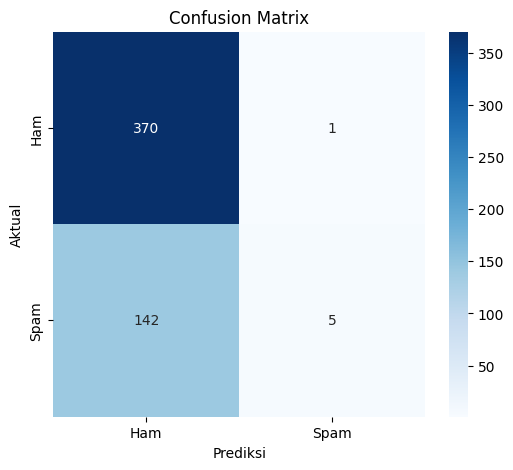

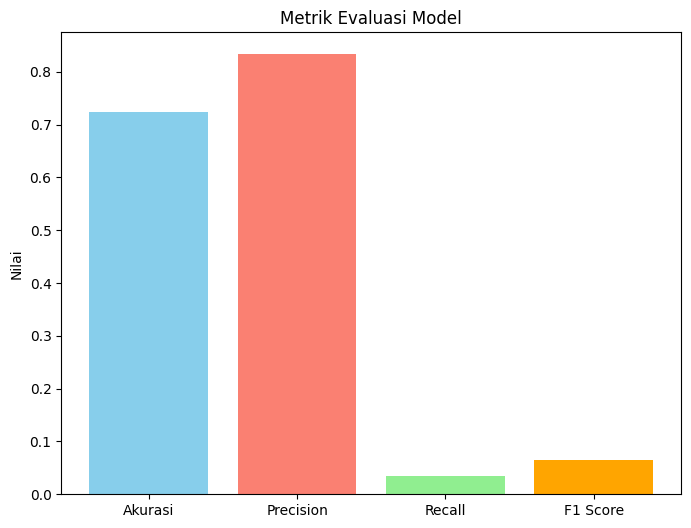

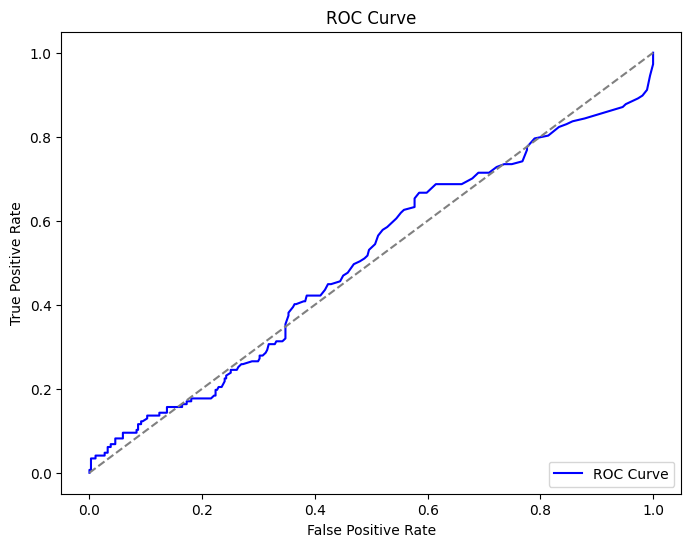

In [ ]:
!pip install scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')

# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)

# 1. Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# 2: Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(int).tolist()  # Pastikan label berupa integer untuk klasifikasi

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]

# 3. Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.1, random_state=42)

# 4. Latih model regresi logistik menggunakan fitur langsung (tanpa ekstraksi fitur)
model = LogisticRegression(max_iter=1000)

# Misalnya kita hanya melatih model dengan panjang email atau fitur numerik lain
# Sebagai contoh, kita hanya akan menggunakan panjang email sebagai fitur numerik
X_train_len = np.array([len(email.split()) for email in X_train]).reshape(-1, 1)
X_test_len = np.array([len(email.split()) for email in X_test]).reshape(-1, 1)

model.fit(X_train_len, y_train)

# 5. Prediksi dan evaluasi model
y_pred = model.predict(X_test_len)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_len)[:, 1])  # ROC AUC menggunakan probabilitas

# Menampilkan hasil metrik evaluasi
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

# 6. Prediksi untuk email baru (gunakan panjang email sebagai fitur untuk prediksi)
input_mail = ["this is my grade"]

# Menghitung panjang email baru
input_mail_len = np.array([len(mail.split()) for mail in input_mail]).reshape(-1, 1)

# Prediksi klasifikasi spam
spam_prediction = model.predict(input_mail_len)
print(f"Prediksi Klasifikasi: {'Spam' if spam_prediction[0] == 1 else 'Ham'}")

# 7. Visualisasi
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Grafik Precision, Recall, F1-Score
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Akurasi', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_len)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Tanpa ekstaksi fitur (dipisah-pisah)

In [ ]:
!pip install scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')

# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'stopwords' is not defined

In [ ]:
# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)

In [ ]:
# 1. Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# 2: Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

In [ ]:
# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(int).tolist()  # Pastikan label berupa integer untuk klasifikasi

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]

In [ ]:
# 3. Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.2, random_state=42)

In [ ]:
# 4. Latih model regresi logistik menggunakan fitur langsung (tanpa ekstraksi fitur)
model = LogisticRegression(max_iter=1000)

# Misalnya kita hanya melatih model dengan panjang email atau fitur numerik lain
# Sebagai contoh, kita hanya akan menggunakan panjang email sebagai fitur numerik
X_train_len = np.array([len(email.split()) for email in X_train]).reshape(-1, 1)
X_test_len = np.array([len(email.split()) for email in X_test]).reshape(-1, 1)

model.fit(X_train_len, y_train)

In [ ]:
# 5. Prediksi dan evaluasi model
y_pred = model.predict(X_test_len)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_len)[:, 1])  # ROC AUC menggunakan probabilitas

# Menampilkan hasil metrik evaluasi
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

In [ ]:
# 6. Prediksi untuk email baru (gunakan panjang email sebagai fitur untuk prediksi)
input_mail = ["this is my grade"]

# Menghitung panjang email baru
input_mail_len = np.array([len(mail.split()) for mail in input_mail]).reshape(-1, 1)

# Prediksi klasifikasi spam
spam_prediction = model.predict(input_mail_len)
print(f"Prediksi Klasifikasi: {'Spam' if spam_prediction[0] == 1 else 'Ham'}")

In [ ]:
# 7. Visualisasi
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Grafik Precision, Recall, F1-Score
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Akurasi', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_len)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Unnamed: 0 label                                               text  \
0         605   ham  subject enron methanol meter follow note gave ...   
1        2349   ham  subject hpl nom januari see attach file hplnol...   
2        3624   ham  subject neon retreat ho ho ho around wonder ti...   
3        4685  spam  subject photoshop window offic cheap main tren...   
4        2030   ham  subject indian spring deal book teco pvr reven...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Data numerik (panjang email) sebelum regresi telah disimpan sebagai CSV:
train_data_numerical.csv dan test_data_numerical.csv
Akurasi: 0.7239382239382239
Precision: 0.8333333333333334
Recall: 0.034013605442176874
F1 Score: 0.06535947712418301
ROC AUC: 0.5041898160881604
Prediksi Klasifikasi: Ham


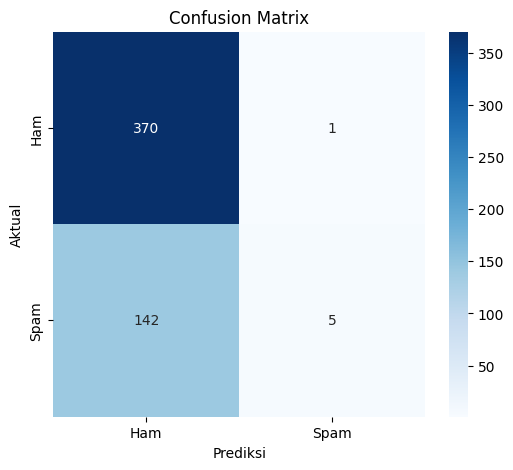

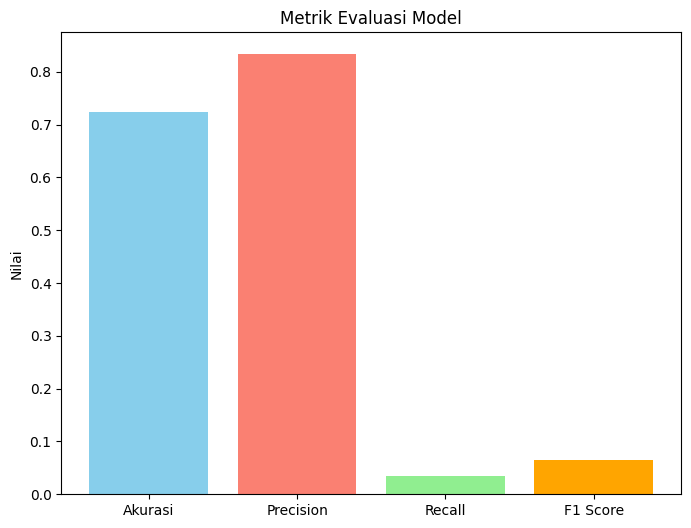

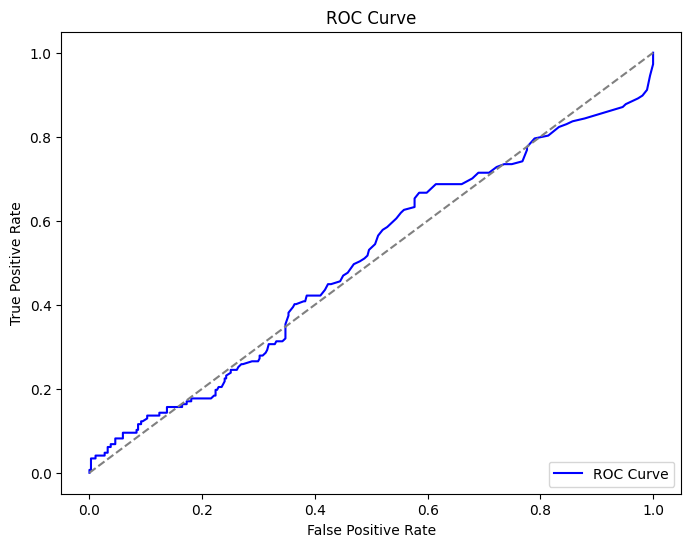

In [ ]:
!pip install scikit-learn matplotlib seaborn nltk

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Pastikan untuk mengunduh stopwords jika belum
nltk.download('stopwords')

# Inisialisasi stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Fungsi untuk preprocessing teks
def preprocess_text(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisasi
    tokens = text.split()
    # Menghapus stopwords dan stemming
    tokens = [stemmer.stem(word) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)

# 1. Baca dataset
dataset_path = "spam_ham_dataset.csv"  # Ganti dengan path file dataset Anda
df = pd.read_csv(dataset_path)

# 2: Periksa dan perbaiki format input
df["text"] = df["text"].fillna("")  # Mengisi NaN dengan string kosong
df["text"] = df["text"].astype(str)  # Pastikan semua nilai berupa string

# Preprocessing data
df["text"] = df["text"].apply(preprocess_text)

# Tampilkan hasil untuk memverifikasi
print(df.head())  # Untuk memastikan data sudah benar

# Pastikan dataset memiliki kolom "Email" dan "Label"
emails = df["text"].tolist()
labels = df["label_num"].astype(int).tolist()  # Pastikan label berupa integer untuk klasifikasi

# Filter out empty emails
emails = [email for email in emails if email.strip() != ""]

# 3. Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.1, random_state=42)

# 4. Latih model regresi logistik menggunakan fitur langsung (tanpa ekstraksi fitur)
model = LogisticRegression(max_iter=1000)

# Menghitung panjang email untuk X_train dan X_test
X_train_len = np.array([len(email.split()) for email in X_train]).reshape(-1, 1)
X_test_len = np.array([len(email.split()) for email in X_test]).reshape(-1, 1)

# Menyimpan data numerik (panjang email) sebelum regresi dalam DataFrame
train_data = pd.DataFrame({
    'Email': X_train,
    'Panjang Email': [len(email.split()) for email in X_train],
    'Label': y_train
})

test_data = pd.DataFrame({
    'Email': X_test,
    'Panjang Email': [len(email.split()) for email in X_test],
    'Label': y_test
})

# Menyimpan data numerik dalam format CSV
train_data.to_csv("train_data_numerical.csv", index=False)
test_data.to_csv("test_data_numerical.csv", index=False)

# Menyimpan hasil untuk verifikasi
print("Data numerik (panjang email) sebelum regresi telah disimpan sebagai CSV:")
print("train_data_numerical.csv dan test_data_numerical.csv")

# Latih model
model.fit(X_train_len, y_train)

# 5. Prediksi dan evaluasi model
y_pred = model.predict(X_test_len)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_len)[:, 1])  # ROC AUC menggunakan probabilitas

# Menampilkan hasil metrik evaluasi
print(f"Akurasi: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

# 6. Prediksi untuk email baru (gunakan panjang email sebagai fitur untuk prediksi)
input_mail = ["this is my grade"]

# Menghitung panjang email baru
input_mail_len = np.array([len(mail.split()) for mail in input_mail]).reshape(-1, 1)

# Prediksi klasifikasi spam
spam_prediction = model.predict(input_mail_len)
print(f"Prediksi Klasifikasi: {'Spam' if spam_prediction[0] == 1 else 'Ham'}")

# 7. Visualisasi
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Grafik Precision, Recall, F1-Score
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Akurasi', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_len)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()
